# Optimal Scheduling of Dynamic Transport: 1D Analytical Tests

Tsimpos, Ren, Zech & Marzouk (2024) show that for the interpolant $X_\tau(x,t) = (1-\tau(t))x + \tau(t)T(x)$, where $T$ is the optimal-transport map between $\mu$ and $\nu$, there exists a closed-form schedule $\tau_\infty$ (Theorem 6) that minimises the worst-case spatial Lipschitz constant of the induced velocity field over all time. The hypothesis tested here is that $\tau_\infty$ keeps $\sup_x |\partial_x v(x,t)|$ uniformly bounded across $t \in [0,1]$, whereas the trivial (linear) schedule $\tau(t) = t$ blows up near the endpoints whenever $T'$ is far from 1.

In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from typing import Callable, Tuple

## Helpers

In [2]:
def ot_map_1d(F_mu, F_nu_inv):
    """T(x) = F_nu_inv(F_mu(x)) — 1-D OT map from mu to nu."""
    def T(x):
        return F_nu_inv(F_mu(np.asarray(x, dtype=np.float64)))
    return T

In [3]:
def T_prime_1d(f_mu, f_nu, T):
    """T'(x) = f_mu(x) / f_nu(T(x))."""
    def Tp(x):
        x = np.asarray(x, dtype=np.float64)
        return f_mu(x) / f_nu(T(x))
    return Tp

In [4]:
def compute_sigma_extrema(T_prime_fn, x_grid):
    """(sigma_max, sigma_min) = (max T', min T') on x_grid."""
    vals = T_prime_fn(np.asarray(x_grid, dtype=np.float64))
    return float(vals.max()), float(vals.min())

In [5]:
def tau_infinity(sigma_max, sigma_min):
    """
    Closed-form optimal schedule tau_inf (Theorem 6, Tsimpos et al. 2024).

    Uses notation f* = sigma_max - 1, g* = sigma_min - 1.

    Case B (f* >= -g*):  tau(t) = (sigma_max^t - 1) / (sigma_max - 1)
    Case C (f* <  -g*):  tau(t) = (sigma_min^t - 1) / (sigma_min - 1)
    Case A (piecewise):  applied when 0 <= t0 <= 1 (not needed for constant T').

    Returns (tau, tau_dot, t0).  t0 is None for single-piece schedules.
    """
    f_star = sigma_max - 1.0
    g_star = sigma_min - 1.0

    if abs(f_star) < 1e-12 and abs(g_star) < 1e-12:
        # Identity map: trivial schedule
        tau     = lambda t: np.asarray(t, dtype=np.float64)
        tau_dot = lambda t: np.ones_like(np.asarray(t, dtype=np.float64))
        return tau, tau_dot, None

    if f_star >= -g_star:           # Case B
        r = float(sigma_max)
    else:                           # Case C
        r = float(sigma_min)

    def tau(t):
        t = np.asarray(t, dtype=np.float64)
        return (r**t - 1.0) / (r - 1.0)

    def tau_dot(t):
        t = np.asarray(t, dtype=np.float64)
        return r**t * np.log(r) / (r - 1.0)

    return tau, tau_dot, None

In [6]:
def flow_map(T, tau):
    """X_tau(x, t) = (1 - tau(t)) * x + tau(t) * T(x)."""
    def X(x, t):
        x = np.asarray(x, dtype=np.float64)
        tau_t = float(tau(t))
        return (1.0 - tau_t) * x + tau_t * T(x)
    return X

In [7]:
def velocity_field(T, tau, tau_dot):
    """
    Eulerian velocity v(y, t) = tau_dot(t) * (T(x) - x), x = X_tau^{-1}(y, t).

    Inversion exploits monotonicity of X_tau via np.interp on a fine Lagrangian grid.
    """
    def v(y, t, x_fine=None):
        y = np.asarray(y, dtype=np.float64)
        tau_t     = float(tau(t))
        tau_dot_t = float(tau_dot(t))
        if x_fine is None:
            x_fine = np.linspace(y.min() - 3.0, y.max() + 3.0, 8000, dtype=np.float64)
        Tx        = T(x_fine)
        X_tau     = (1.0 - tau_t) * x_fine + tau_t * Tx
        v_lagr    = tau_dot_t * (Tx - x_fine)
        return np.interp(y, X_tau, v_lagr)
    return v

In [8]:
def lipschitz_constant(velocity_fn, t_grid, x_grid):
    """
    Estimate L(t) = sup_x |partial_x v(x, t)| via finite differences on x_grid.
    velocity_fn signature: v(y, t) -> array.
    """
    x_grid = np.asarray(x_grid, dtype=np.float64)
    dx = x_grid[1] - x_grid[0]
    L  = np.empty(len(t_grid), dtype=np.float64)
    for i, t in enumerate(t_grid):
        v_vals = velocity_fn(x_grid, t, x_grid)
        L[i]   = np.max(np.abs(np.diff(v_vals) / dx))
    return L

In [9]:
_BLUE   = "#2563EB"   # trivial schedule
_ORANGE = "#EA580C"   # optimal schedule

def plot_trajectories(T_fn, tau_trivial, tau_optimal, x0_samples, t_grid, title=""):
    """Side-by-side trajectory plots: trivial vs optimal schedule."""
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
    for ax, tau_fn, label, color in zip(
        axes,
        [tau_trivial, tau_optimal],
        ["Trivial  tau(t)=t", "Optimal  tau_inf(t)"],
        [_BLUE, _ORANGE],
    ):
        for x0 in x0_samples:
            traj = np.array([(1 - float(tau_fn(t))) * x0 + float(tau_fn(t)) * float(T_fn(x0))
                             for t in t_grid])
            ax.plot(t_grid, traj, color=color, lw=0.8, alpha=0.6)
        ax.set_xlabel("t")
        ax.set_ylabel("x")
        ax.set_title(label)
        ax.grid(True, lw=0.3)
    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

def plot_schedule(tau_trivial, tau_dot_trivial, tau_optimal, tau_dot_optimal, t_grid, title=""):
    """Plot tau(t) and tau_dot(t) for trivial and optimal schedules."""
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    t = t_grid

    axes[0].plot(t, [tau_trivial(s) for s in t],  color=_BLUE,   lw=2, label="trivial")
    axes[0].plot(t, [tau_optimal(s) for s in t],  color=_ORANGE, lw=2, label="optimal")
    axes[0].set_xlabel("t"); axes[0].set_ylabel("tau(t)")
    axes[0].set_title("Schedule"); axes[0].legend(); axes[0].grid(True, lw=0.3)

    axes[1].plot(t, [tau_dot_trivial(s) for s in t],  color=_BLUE,   lw=2, label="trivial")
    axes[1].plot(t, [tau_dot_optimal(s) for s in t],  color=_ORANGE, lw=2, label="optimal")
    axes[1].set_xlabel("t"); axes[1].set_ylabel("tau_dot(t)")
    axes[1].set_title("Schedule derivative"); axes[1].legend(); axes[1].grid(True, lw=0.3)

    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

def plot_lipschitz(L_trivial, L_optimal, t_grid, title=""):
    """Semilog plot of the spatial Lipschitz constant vs time."""
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.semilogy(t_grid, L_trivial, color=_BLUE,   lw=2, label="trivial")
    ax.semilogy(t_grid, L_optimal, color=_ORANGE, lw=2, label="optimal")
    ax.axhline(np.log(100), color="gray", lw=1, ls="--", label=r"$\ln(100)$ (theoretical)")
    ax.set_xlabel("t"); ax.set_ylabel(r"$L(t) = \sup_x |\partial_x v(x,t)|$")
    ax.set_title(title or "Spatial Lipschitz constant of velocity field")
    ax.legend(); ax.grid(True, which="both", lw=0.3)
    plt.tight_layout()
    plt.show()

## Test case 1: Gaussian → Gaussian (θ₂ ≪ θ₁)

In [10]:
# N(0,1) -> N(0, 0.01^2)
sigma1, sigma2 = 1.0, 0.01

mu_src = stats.norm(loc=0.0, scale=sigma1)
mu_tgt = stats.norm(loc=0.0, scale=sigma2)

f_mu      = mu_src.pdf
F_mu      = mu_src.cdf
F_nu_inv  = mu_tgt.ppf
f_nu      = mu_tgt.pdf

# Lagrangian grid over the support of mu (clip tails to avoid numerical issues)
x_grid = np.linspace(-4.0, 4.0, 2000, dtype=np.float64)

T        = ot_map_1d(F_mu, F_nu_inv)
Tp       = T_prime_1d(f_mu, f_nu, T)

# Sanity check: T(x) should equal sigma2/sigma1 * x = 0.01 x
print(f"T(1.0) = {T(np.array([1.0]))[0]:.6f}  (expected {sigma2/sigma1:.6f})")
print(f"T'(0.0) = {Tp(np.array([0.0]))[0]:.6f}  (expected {sigma2/sigma1:.6f})")

T(1.0) = 0.010000  (expected 0.010000)
T'(0.0) = 0.010000  (expected 0.010000)


In [11]:
sigma_max, sigma_min = compute_sigma_extrema(Tp, x_grid)
print(f"sigma_max = {sigma_max:.6f},  sigma_min = {sigma_min:.6f}")

# Trivial schedule
tau_triv     = lambda t: np.asarray(t, dtype=np.float64)
tau_dot_triv = lambda t: np.ones_like(np.asarray(t, dtype=np.float64))

# Optimal schedule
tau_opt, tau_dot_opt, t0 = tau_infinity(sigma_max, sigma_min)
print(f"tau_opt(0) = {tau_opt(0.0):.4f}  (expected 0)")
print(f"tau_opt(1) = {tau_opt(1.0):.4f}  (expected 1)")
print(f"t0 = {t0}")

sigma_max = 0.010000,  sigma_min = 0.010000
tau_opt(0) = -0.0000  (expected 0)
tau_opt(1) = 1.0000  (expected 1)
t0 = None


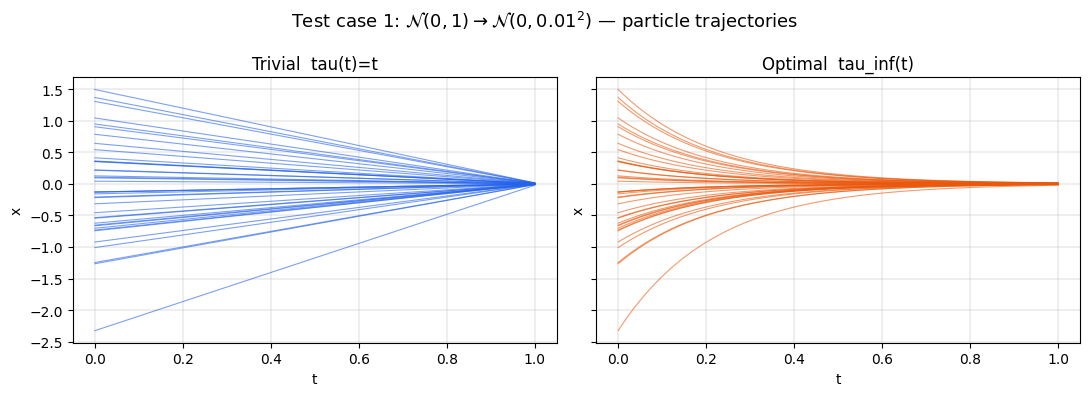

In [12]:
rng       = np.random.default_rng(0)
x0_samp   = rng.standard_normal(40)
t_dense   = np.linspace(0.0, 1.0, 200)

plot_trajectories(
    T, tau_triv, tau_opt, x0_samp, t_dense,
    title=r"Test case 1: $\mathcal{N}(0,1) \to \mathcal{N}(0,0.01^2)$ — particle trajectories",
)

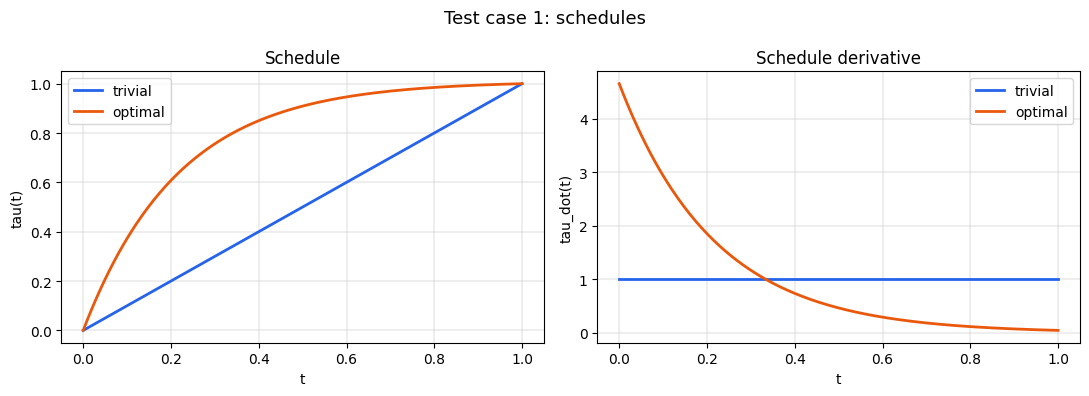

In [13]:
t_plot = np.linspace(0.0, 1.0, 300)
plot_schedule(
    tau_triv, tau_dot_triv, tau_opt, tau_dot_opt, t_plot,
    title=r"Test case 1: schedules",
)

Trivial  L max = 66.22,  L at t=0.99 ≈ 66.22
Optimal  L max = 4.6052,  theoretical = 4.6052


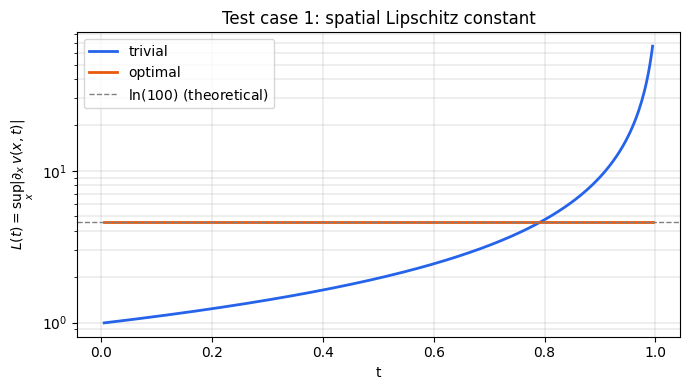

In [14]:
# Exclude t very close to 0 and 1 to avoid division-by-zero for the trivial schedule
t_lip  = np.linspace(0.005, 0.995, 400)
x_eval = np.linspace(-3.5 * sigma1, 3.5 * sigma1, 1500, dtype=np.float64)

v_triv = velocity_field(T, tau_triv, tau_dot_triv)
v_opt  = velocity_field(T, tau_opt,  tau_dot_opt)

L_triv = lipschitz_constant(v_triv, t_lip, x_eval)
L_opt  = lipschitz_constant(v_opt,  t_lip, x_eval)

print(f"Trivial  L max = {L_triv.max():.2f},  L at t=0.99 ≈ {L_triv[-1]:.2f}")
print(f"Optimal  L max = {L_opt.max():.4f},  theoretical = {np.log(1/sigma2):.4f}")

plot_lipschitz(
    L_triv, L_opt, t_lip,
    title=r"Test case 1: spatial Lipschitz constant",
)

## Test case 2: Gaussian → bimodal Gaussian mixture

## Test case 3: Gaussian → Laplace

## Test case 4: Uniform → peaked Gaussian

## Summary